In [13]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description

from model import build_1d_cnn_model
import common


BATCH_SIZE=1
recordfile="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data1120000.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"#"/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,44,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example).shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0
for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label#[:88] # Assuming 88 notes
    pred_active = pred#[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))

print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


Initial input shape: (1, 148, 512)
After first Conv2D: (1, 74, 64)
Extracting string from filters 0 to 10
String 0 section shape: (1, 10, 64)
String 0 after first Conv1D: (1, 10, 128)
Extracting string from filters 11 to 20
String 11 section shape: (1, 9, 64)
String 11 after first Conv1D: (1, 9, 128)
Extracting string from filters 21 to 30
String 21 section shape: (1, 9, 64)
String 21 after first Conv1D: (1, 9, 128)
Extracting string from filters 31 to 38
String 31 section shape: (1, 7, 64)
String 31 after first Conv1D: (1, 7, 128)
Extracting string from filters 39 to 48
String 39 section shape: (1, 9, 64)
String 39 after first Conv1D: (1, 9, 128)
Extracting string from filters 49 to 73
String 49 section shape: (1, 24, 64)
String 49 after first Conv1D: (1, 24, 128)
Total True Positives: 2213
Total False Positives: 852
Total False Negatives: 3359
Precision: 0.7220228384968287
Recall: 0.3971643933948364


In [14]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 44)
Shape of tp (44,)
precision: [0.86       0.83333333 0.77777778 0.96385542 1.         0.79354839
 0.41666667 0.94594595 0.03061224 0.7368421  0.83076923 0.875
 0.68108108 0.53846154 0.61764706 0.88615385 0.53846154 0.67333333
 0.28571429 0.57333333 0.15789474 0.62280702 0.88493151 0.9
 0.72438163 0.37142857 0.66666667 0.95689655 0.90322581 0.52272727
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
recall: [0.18376068 0.3125     0.30434783 0.20460358 0.1        0.384375
 0.09803922 0.1511879  0.33333333 0.19178082 0.43113772 0.10294118
 0.68478261 0.60869565 0.22105263 0.55598456 0.12280702 0.6102719
 0.20689655 0.44559585 0.27272727 0.59663866 0.54931973 0.10843373
 0.60650888 0.39393939 0.34042553 0.28461538 0.48275862 0.74193548
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.      

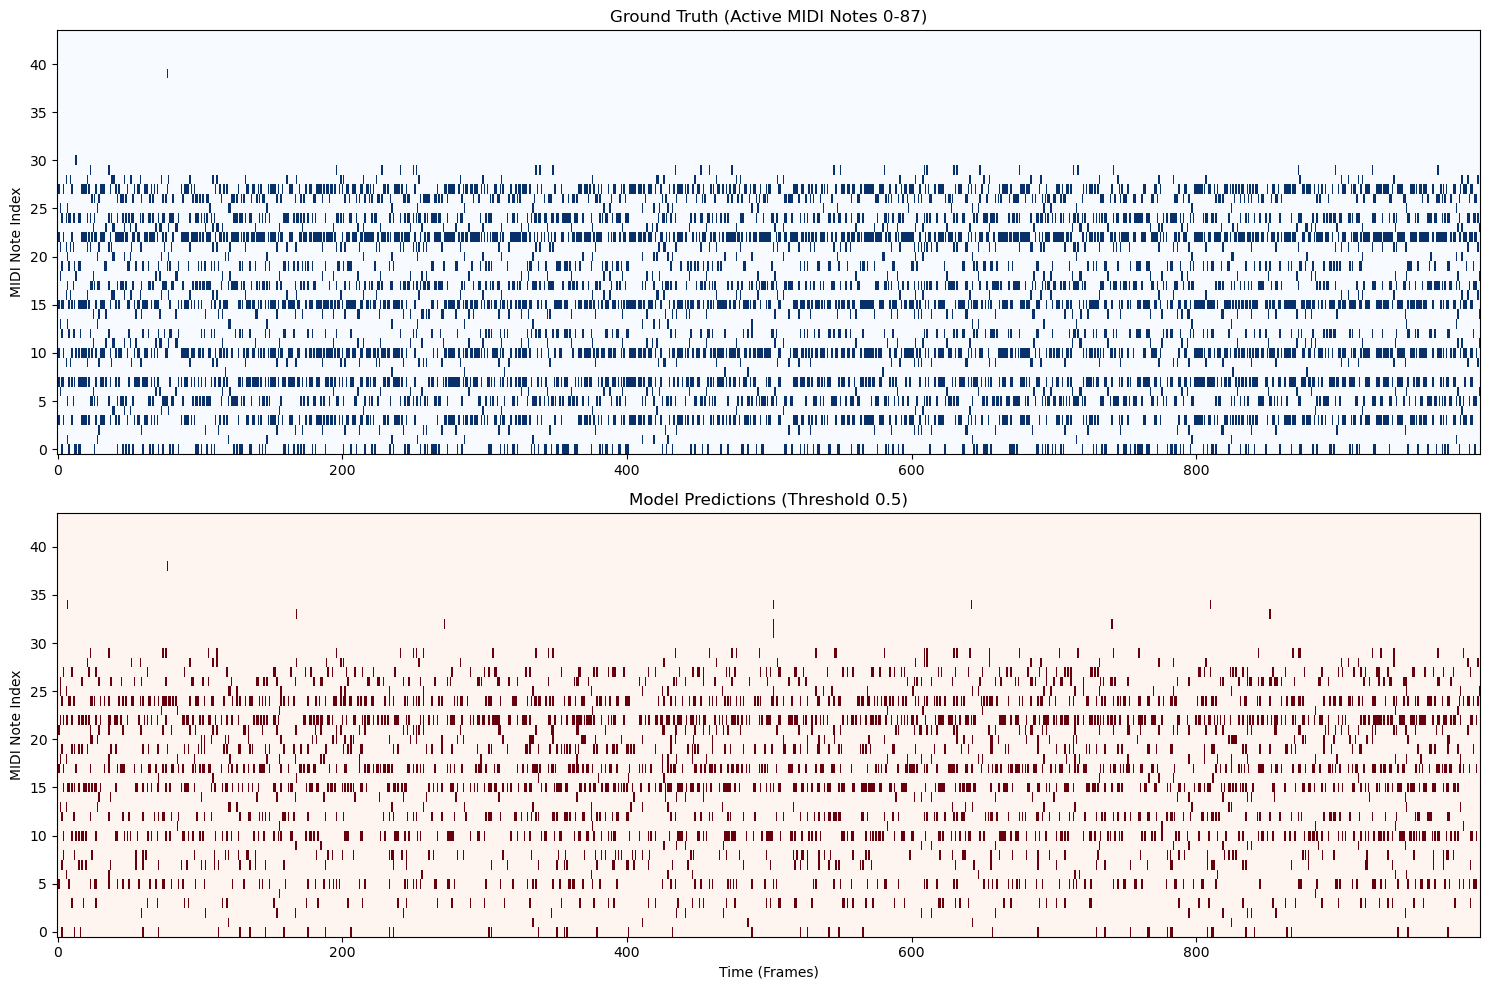

In [15]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()